# How do the residuals look like?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import sys
from pathlib import Path

project_root = Path("/Users/kristineandersen/Desktop/Speciale/Thesis_project")
sys.path.append(str(project_root))

from Scripts.Preliminary_Predictions_S2 import *


Working directory set to: /Users/kristineandersen/Desktop/Speciale/Thesis_project


In [2]:
errors = y_val - val_pred

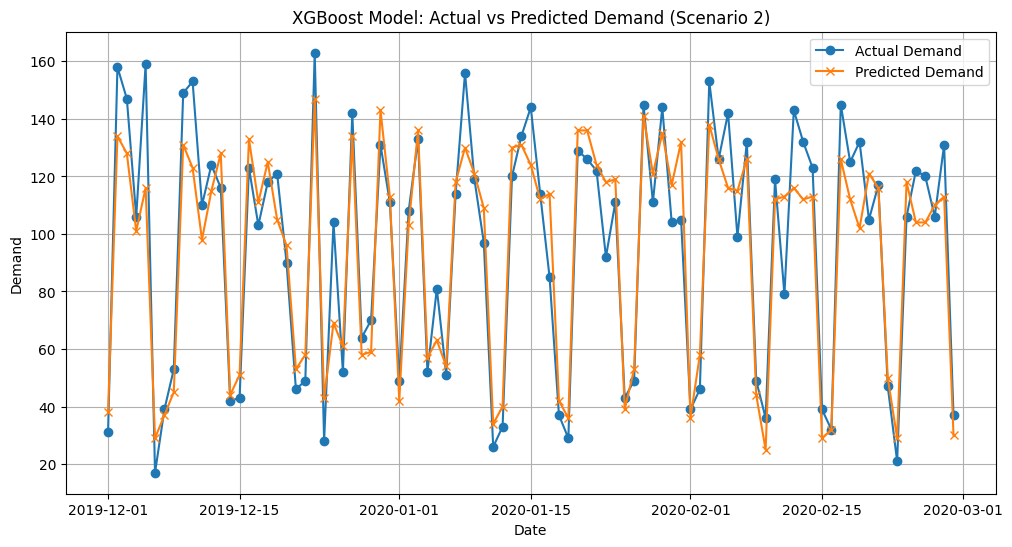

In [3]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg['date'], S2_daily_agg['n'], label='Actual Demand', marker='o')
plt.plot(S2_daily_agg['date'], S2_daily_agg['predicted'], label='Predicted Demand', marker='x')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('XGBoost Model: Actual vs Predicted Demand (Scenario 2)')
plt.legend()
plt.grid()
plt.show()

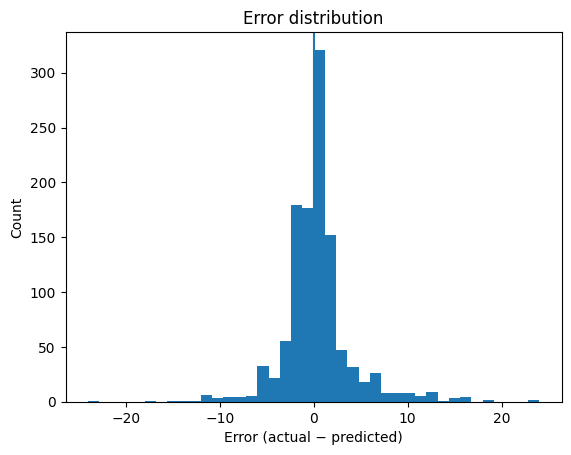

In [4]:
plt.hist(errors, bins=40)
plt.axvline(0)
plt.xlabel("Error (actual − predicted)")
plt.ylabel("Count")
plt.title("Error distribution")
plt.show()


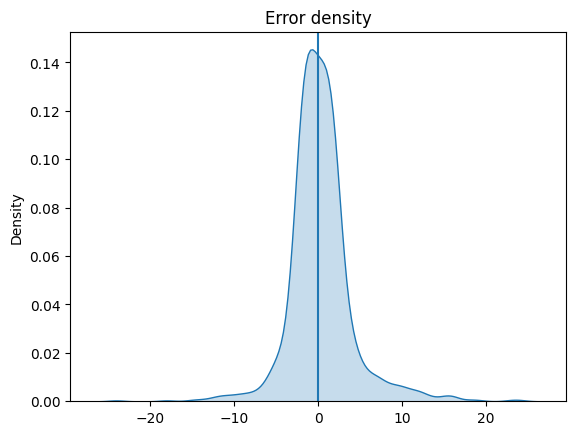

In [5]:
sns.kdeplot(errors, fill=True)
plt.axvline(0)
plt.title("Error density")
plt.show()


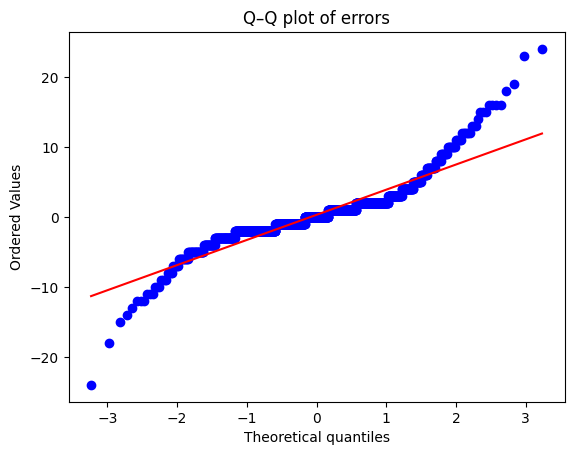

In [6]:
stats.probplot(errors, dist="norm", plot=plt)
plt.title("Q–Q plot of errors")
plt.show()

# Different CI's

## Baseline (Residual-based: Empirical)
As I cannot assume the errors are normal (based on the above plots), we make the baseline emperical

In [11]:
from Scripts.CI_baseline import *

        date    n  predicted  lower_90  upper_90
0 2020-02-15   39       27.0       6.0      57.0
1 2020-02-16   32       30.0       4.0      72.0
2 2020-02-17  145      124.0      60.0     214.0
3 2020-02-18  125      117.0      52.0     207.0
4 2020-02-19  132      102.0      48.0     174.0


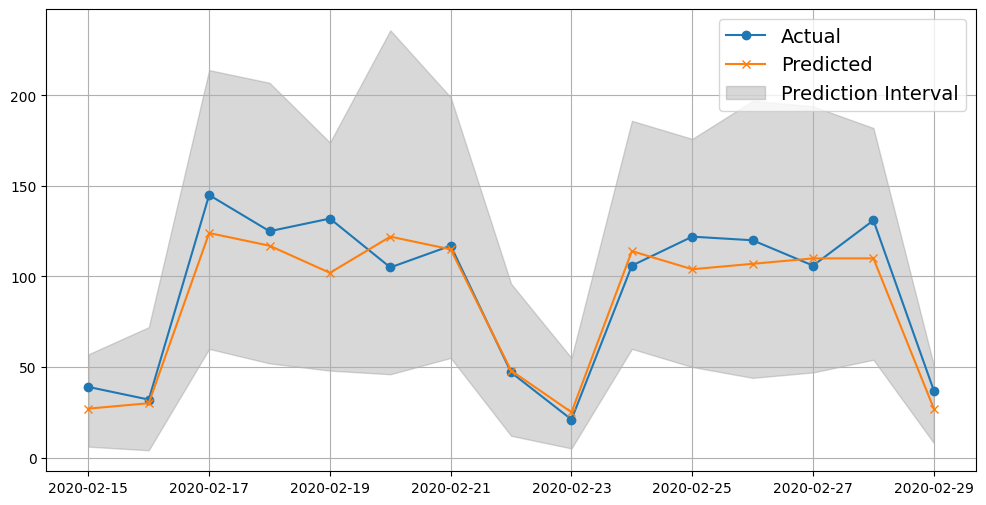

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg_baseline['date'], S2_daily_agg_baseline['n'], marker='o', label='Actual')
plt.plot(S2_daily_agg_baseline['date'], S2_daily_agg_baseline['predicted'], marker='x', label='Predicted')
plt.fill_between(S2_daily_agg_baseline['date'], S2_daily_agg_baseline['lower_90'], S2_daily_agg_baseline['upper_90'], alpha=0.3, color="gray", label="Prediction Interval")
plt.legend(fontsize=14)
plt.grid()
plt.show()


In [4]:
coverage_baseline = np.mean(
    (test_daily['n'] >= S2_daily_agg_baseline['lower_90']) & (test_daily['n'] <= S2_daily_agg_baseline['upper_90'])
)
print("90% interval coverage:", coverage_baseline)

width_baseline = np.mean(S2_daily_agg_baseline['upper_90'] - S2_daily_agg_baseline['lower_90'])
width_std_baseline = np.std(S2_daily_agg_baseline['upper_90'] - S2_daily_agg_baseline['lower_90'])
print("Quantile XGB avg width:", width_baseline)
print("Quantile XGB width std:", width_std_baseline)

90% interval coverage: 1.0
Quantile XGB avg width: 116.33333333333333
Quantile XGB width std: 44.14773179023156


## XGB Quantile regression

In [8]:
from Scripts.CI_XGBQuantile import *

        date    n  predicted  lower_90  upper_90
0 2020-02-15   39       27.0       8.0      57.0
1 2020-02-16   32       32.0       9.0      64.0
2 2020-02-17  145      120.0      51.0     206.0
3 2020-02-18  125      113.0      47.0     198.0
4 2020-02-19  132      100.0      42.0     173.0


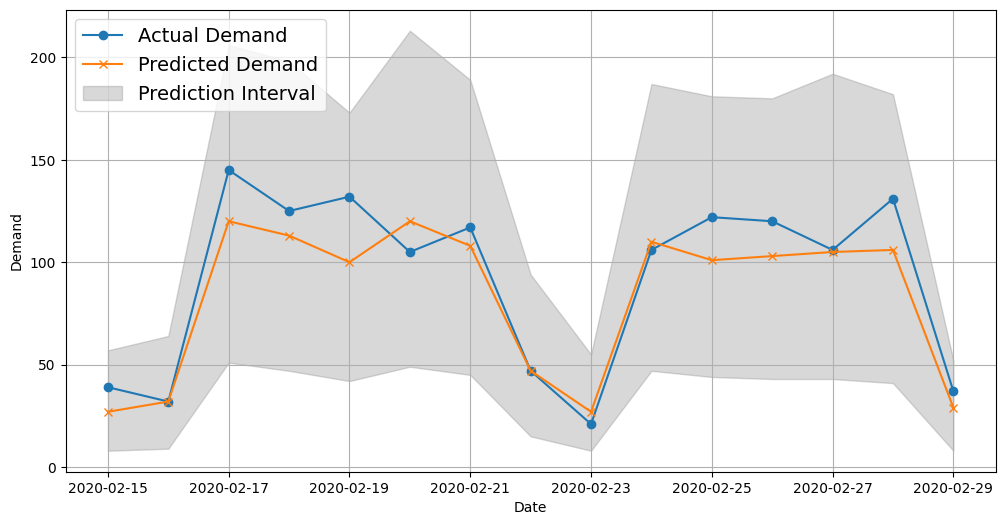

In [10]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg["date"], S2_daily_agg["n"], label="Actual Demand", marker="o")
plt.plot(S2_daily_agg["date"], S2_daily_agg["predicted"], label="Predicted Demand", marker="x")
plt.fill_between(
    S2_daily_agg["date"],
    S2_daily_agg["lower_90"],
    S2_daily_agg["upper_90"],
    color="gray",
    alpha=0.3,
    label="Prediction Interval"
)
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend(fontsize=14)
plt.grid()
plt.show()

In [7]:
coverage_xgb = np.mean(
    (test_daily['n'] >= S2_daily_agg['lower_90']) & (test_daily['n'] <= S2_daily_agg['upper_90'])
)
print("90% interval coverage:", coverage_xgb)


width_xgb = np.mean(S2_daily_agg['upper_90'] - S2_daily_agg['lower_90'])
width_std_xgb = np.std(S2_daily_agg['upper_90'] - S2_daily_agg['lower_90'])
print("Quantile XGB avg width:", width_xgb)
print("Quantile XGB width std:", width_std_xgb)

90% interval coverage: 1.0
Quantile XGB avg width: 114.86667
Quantile XGB width std: 43.768887


## Bootstrap

In [3]:
from Scripts.CI_bootstrap_rev import *

        date    n  predicted  lower  upper
0 2020-02-15   39       27.0   16.0   47.0
1 2020-02-16   32       30.0   17.0   54.0
2 2020-02-17  145      124.0  107.0  162.0
3 2020-02-18  125      117.0  100.0  155.0
4 2020-02-19  132      102.0   86.0  135.0


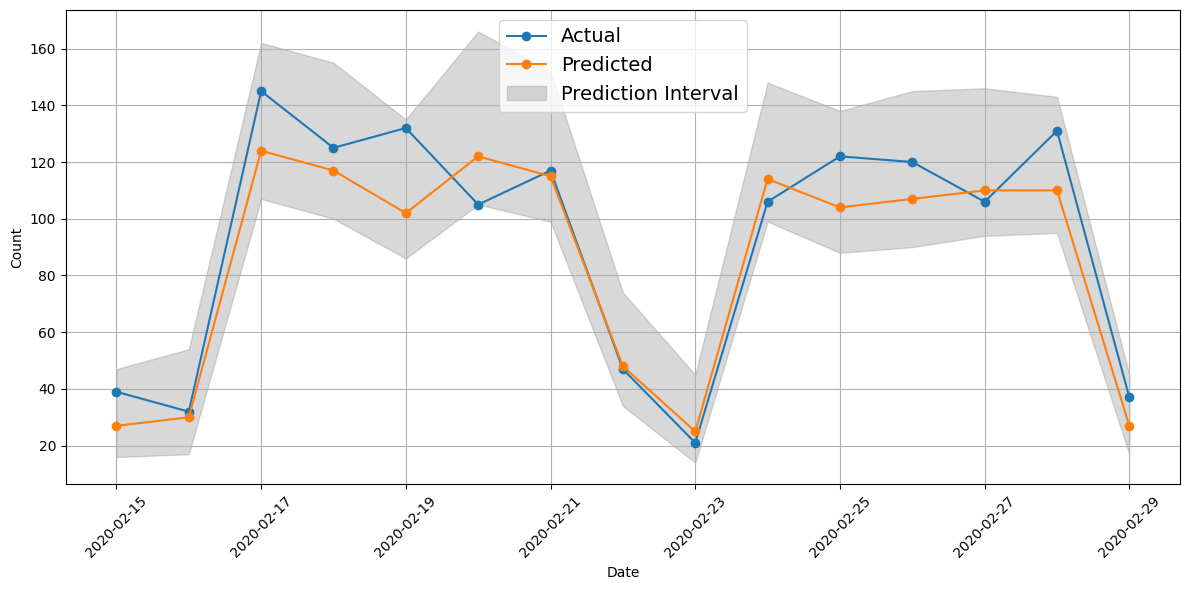

In [4]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(daily["date"], daily["n"], label="Actual", marker="o")
plt.plot(daily["date"], daily["predicted"], label="Predicted", marker="o")
plt.fill_between(daily["date"], daily["lower"], daily["upper"], color="gray", alpha=0.3, label="Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend(fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

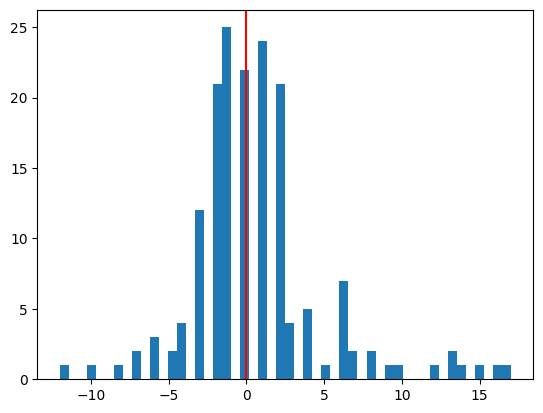

In [5]:
plt.hist(res, bins=50)
plt.axvline(0, color="red")
plt.show()

In [6]:
np.quantile(res, [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

array([-8.64, -5.  , -2.  ,  0.  ,  2.  ,  8.6 , 15.32])

In [7]:
print(res.mean())
print(res.std())

0.6094674556213018
4.309220094507284


In [4]:
# coverage
coverage_bootstrap = np.mean((daily["n"] >= daily["lower"]) & (daily["n"] <= daily["upper"]))
print(f"Coverage of Simulation Band: {coverage_bootstrap:.2%}")
# width
daily["bandwidth"] = daily["upper"] - daily["lower"]
width_bootstrap = daily["bandwidth"].mean()
width_std_bootstrap = daily["bandwidth"].std()
print(f"Average Bandwidth: {width_bootstrap:.2f}")
print(f"Standard Deviation of Bandwidth: {width_std_bootstrap:.2f}")

Coverage of Simulation Band: 90.11%
Average Bandwidth: 45.02
Standard Deviation of Bandwidth: 8.13


In [18]:
# Create a dictionary with the methods, coverages, and widths
comparison_data = {
    "Method": [
        "Baseline", 
        "XGB Quantile Regression", 
        "Bootstrap"
    ],
    "Coverage": [
        coverage_baseline, 
        coverage_xgb, 
        coverage_bootstrap
    ],
    "Avg Width": [
        width_baseline, 
        width_xgb, 
        width_bootstrap
    ],
    "Width Std": [
        width_std_baseline, 
        width_std_xgb, 
        width_std_bootstrap
    ]
}

# Create a DataFrame
comparison_table = pd.DataFrame(comparison_data)

# Display the table
print(comparison_table)



                    Method  Coverage   Avg Width  Width Std
0                 Baseline  1.000000  138.791209  46.495543
1  XGB Quantile Regression  1.000000  124.483513  42.046642
2                Bootstrap  0.901099   45.023626   8.129409
